# 02_bracket_simulations.ipynb

The objective of this notebook is to explore the use of Monte Carlo methods to simulate playoff brackets, given our Elo ratings.

# Desired output of simulations

For our complete system of choosing the optimal roster, the primary objective of the simulations is to output the expected number of games each team will play in the playoffs, given their starting bracket.

By consequence of this goal we will also be able to predict who the most probable Stanley Cup winner will be, which is fun.


# NHL playoffs format
The Stanley Cup playoffs consists of four rounds of best-of-seven series. Each series is aplyed in a 2-2-1-1-1 format, meaning the team with home-ice advantage hosts games one, two, five, and seven and the other team hosts games three, four, and six. Games five, six, and seven are only played if needed.

## Teams
There are 16 teams in total, with eight teams in each conference qualifying for the playoffs.

The first, second, and third placed teams in each of the four divisions qualify for the playoffs automatically. Two additional teams from each conference (regardless of division) make the playoffs as wildcards.

## First Round
Teams are split into two brackets per conference. Each bracket consists of the three divisional qualifiers and one of the wild cards.

The division winner with the best record plays the lowest seeded wildcard. The other division winner plays against the other wildcard. The other two series match the second and third place teams from their respective divisions.

So each conference will have a bracket set up like 

Division 1: 
- D1 vs. WC1 
- D2 vs. D3

Division 2: 
- D1 vs. WC2 
- D2 vs. D3

Where the D1, D2, D3 are their seeds in their respective divisions.

The higher seeded team in each matchup has home ice advantage.

### Seeding 
Seeding is relative to it's own divisional bracket. We have seeds 1-4 for each division:

Division 1:
- D1 (seed 1)
- D2 (seed 2)
- D3 (seed 3)
- WC  (seed 4)

## Second Round
The winners of the first round advance to the second round.

Let's say that in the Division 1 example above, WC1 and D2 win their respective series. These two team will play each other in the second round.

The higher seeded team in each matchup has home ice advantage.

## Third Round
The winners of the second round advance to the third round.

The third round are the conference finals.

The team with the better regular season record (regardless of seeding) has home ice advantage.

## Fourth Round
The winners of the third round advance to the fourth round.

The fourth round are the Stanley Cup Finals.

The team with the better regular season record (regardless of seeding) has home ice advantage.

## Tie-Breaking Procedure

In the case of ties in the regular season record, the league's [tie-breaking procedure](https://en.wikipedia.org/wiki/Season_structure_of_the_NHL#Stanley_Cup_playoffs) is applied. It is based on regulation wins first, and then further criteria if needed.

#### Notes
The team with "the better regular season record" is the team with more points.





# Monte Carlo Methods

At a high level, a Monte Carlo simulation is a computational algorithm that uses repeated random sampling to obtain the likelihood of a range of results of occuring. They are a way to model the probability of different outcomes of a process that can not be easily predicted.

## Simulating one game

Let's start with just trying to simulate one game.

We will have as input to a simulation:
- Home team Elo rating
- Away team Elo rating
- Knowledge of who is the home team (for the home advantage boost)

With this information, we can compute the probability the home team wins, $p_H$. We will then generate a random number (uniform distribution) $u$. If $u < p_H$, then the home team wins, otherwise the away team wins. If we run this many times and collect the results and compute probabilities. This gets more powerful when we try simulating entire series, brackets, playoffs.

### Read in data
First, let's get our Elo ratings for the 2025-2026 regular season.

In [ ]:
from nhl_pool.config import PROCESSED_DIR
import json

ratings_path = PROCESSED_DIR / "20252026" / "regular" / "ratings.json"
with open(ratings_path, 'r') as file:
    ratings = json.load(file)

# Rating of a given team
ratings["EDM"]

1506.8861652059463

The 2024-2025 Stanley Cup finals were between the Florida Panthers and the Edmonton Oilers, so let's start with simulating a game between these two teams.

In [2]:
def elo_compute_win_probability(R_h, R_a, h_adv=30):
    '''Given the Elo ratings for the home and away teams (h and a), compute the probability team h wins.'''
    return 1.0 / (1.0 + 10**((R_a - (R_h + h_adv))/400.0))

In [3]:
import numpy as np
rng = np.random.default_rng(seed=123)
    
def simulate_game(R_h, R_a, rng, h_adv=30):
    '''Returns a boolean 1 if home team won, otherwise home team lost.'''
    
    # Calculate the win probability
    p_home_win = elo_compute_win_probability(R_h, R_a, h_adv=h_adv)
    
    # Random number
    u = rng.random()
    
    return u < p_home_win

We'll simulate a game where EDM is the home team

In [4]:
R_h = ratings["EDM"]
R_a = ratings["FLA"]

p_home_win = elo_compute_win_probability(R_h, R_a)
print(f"Probability EDM win home game: {p_home_win:.4f}")

Probability EDM win home game: 0.5832


Now let's run this many times and compute the probability

In [5]:
n = 100000

wins_EDM = np.zeros(n)

for i in range(n):
    wins_EDM[i] = simulate_game(R_h, R_a, rng)

E_h = np.sum(wins_EDM) / n
E_a = 1 - E_h

print(f"Probability EDM win home game: {E_h:.4f}")
print(f"Probability FLA win away game: {E_a:.4f}")

Probability EDM win home game: 0.5837
Probability FLA win away game: 0.4163


As we might expect, when we run this simple simulation many times we almost recover our direct calculation of home team win probability, $p_H$. This is a good sanity check and can now move on to more complex simulations. 

# Simulating a series

With the confirmation that our simulation method works, we can try and simulte the entire series.

In the 2024-2025 Stanley Cup Finals, EDM was the team with home ice advantage for the best of seven 2-2-1-1-1 format.

Let's try and simulate the a series between these two teams (but using their modelled Elo ratings from the 2025-2026 regular season).


In [6]:
def build_series_home_away_order(homeTeamAbbrev, awayTeamAbbrev):
    '''The homeTeamAbbrev is the teamAbbrev for the team with home ice advantage in the 2-2-1-1-1 format.'''
    # For each game type, the first team will be the home team for that game.
    g1 = (homeTeamAbbrev, awayTeamAbbrev)
    g2 = (awayTeamAbbrev, homeTeamAbbrev)
    
    return [g1, g1, g2, g2, g1, g2, g1] # 2-2-1-1-1


def init_series_outcome_dict(homeTeamAbbrev, awayTeamAbbrev):
    series_outcome = {homeTeamAbbrev: 0,
                   awayTeamAbbrev: 0}
    return series_outcome

def simulate_series(homeTeamAbbrev, awayTeamAbbrev, ratings, rng):
    game_order = build_series_home_away_order(homeTeamAbbrev, awayTeamAbbrev)
    
    series_outcome = init_series_outcome_dict(homeTeamAbbrev, awayTeamAbbrev)
    
    for game in game_order:
        gameHomeTeamAbbrev = game[0]
        gameAwayTeamAbbrev = game[1]
        
        # Extract ratings
        R_h = ratings[gameHomeTeamAbbrev]
        R_a = ratings[gameAwayTeamAbbrev]
        
        # Simulate_game
        home_win = simulate_game(R_h, R_a, rng)
        
        # Update series dict
        series_outcome[gameHomeTeamAbbrev] += home_win
        series_outcome[gameAwayTeamAbbrev] += 1 - home_win
        
        # Exit series simulation if either team has four wins
        if series_outcome[homeTeamAbbrev] == 4 or series_outcome[awayTeamAbbrev] == 4:
            return series_outcome

series_outcome = simulate_series("EDM", "FLA", ratings, rng)
print(series_outcome)

{'EDM': 4, 'FLA': 0}


Now let's simulate this series many times.

In [7]:
series_wins = {
    "EDM": 0,
    "FLA": 0
}

n = 200000

for _ in range(n):
    # Simulate series
    series_outcome = simulate_series("EDM", "FLA", ratings, rng)

    # Determine winner of series
    series_winner_abbrev = max(series_outcome, key=series_outcome.get)
    
    # Update aggregation
    series_wins[series_winner_abbrev] += 1

print(f"Probability EDM wins series: {series_wins["EDM"] / n :.4f}")
print(f"Probability FLA wins series: {series_wins["FLA"] / n:.4f}")

Probability EDM wins series: 0.6017
Probability FLA wins series: 0.3983


According to the simulations, there is a ~60% chance that EDM wins the series.

# Updating Elo during the simulation

Instead of holding the ratings static, for a single simulation run let's try updating the Elo ratings. This way we could try and capture team strength throughout the playoffs as well, for example sometimes teams go on hot streaks. For the next simulation, the ratings will reset to the team's base ratings.

## K-factor
In the Elo ratings calculations, we had a default of $K=20$ for the regular season ratings updates. For the playoffs and the stability of the simulations, the K-factor should probably be reduced such that ratings do not get big swings at this stage. Perhaps $K = 5$ or $K =10$ would be suitable. The playoff Elo updates are driven by simulated outcomes rather than observed results, so we reduce $K$ to avoid amplifying Monte Carlo induced-variance.

## Goal index, OT/SO multipliers
In the Elo ratings calculations we include a goal index and OT/SO multipliers in our ratings. However, in our simulations we only receive the game outcome. Therefore, we will simplify our rating update to omit these.

# What is the home ice advantage in playoff games?
In the `elo_rating.ipynb` notebook, we calculated that in regular season games, the home team won 54.23% of the time (using data from 2010-2025), corresponding to a $h_{adv} \approx 30$. This value could be different for playoff games, so let's calculate it.

In [8]:
import pandas as pd
from nhl_pool.config import GAMES_DIR

games_raw = pd.read_csv(GAMES_DIR)
games_raw['gameId'] = games_raw['gameId'].astype(str)

games_raw_playoffs = games_raw[games_raw["gameType"] == 3]

games_raw_playoffs["homeTeamWin"] = games_raw_playoffs["homeTeamScore"] > games_raw_playoffs["awayTeamScore"]
print(f"Home team win percentage: {100*games_raw_playoffs["homeTeamWin"].sum() / len(games_raw_playoffs):.2f}%")

Home team win percentage: 51.31%


We see that in playoff games, the home team is not as advantaged with the home team winning 51.31% of the time (nearly a coin flip). This percentage corresponds to a $h_{adv} \approx 11$ which we can use going forwards.

In [9]:

def elo_update_home_rating(R_h, E_h, S_h, K=20):
    return float(R_h + K*(S_h - E_h))

def elo_update_away_rating(R_a, E_a, S_a, K=20):
    return float(R_a + K*(S_a - E_a))

def elo_update_ratings(homeTeamAbbrev, awayTeamAbbrev, ratings, home_team_win, K=20, h_adv=11):
    
    # Get current ratings
    R_h = ratings[homeTeamAbbrev]
    R_a = ratings[awayTeamAbbrev]
    
    # Compute home win probability
    E_h = elo_compute_win_probability(R_h, R_a, h_adv=h_adv)
    E_a = 1 - E_h
    
    # Outcome
    S_h = float(int(home_team_win))   # 1.0 if home_win else 0.0
    S_a = 1.0 - S_h
    
    # Updates
    ratings[homeTeamAbbrev] = R_h + K * (S_h - E_h)
    ratings[awayTeamAbbrev] = R_a + K * (S_a - E_a)

    return ratings

In [10]:
def simulate_series(homeTeamAbbrev, awayTeamAbbrev, ratings, rng, K=10, h_adv=11):
    game_order = build_series_home_away_order(homeTeamAbbrev, awayTeamAbbrev)
    
    series_outcome = init_series_outcome_dict(homeTeamAbbrev, awayTeamAbbrev)
    
    for gameHomeTeamAbbrev, gameAwayTeamAbbrev in game_order:
        
        # Extract ratings
        R_h = ratings[gameHomeTeamAbbrev]
        R_a = ratings[gameAwayTeamAbbrev]
        
        # Simulate_game
        home_win = simulate_game(R_h, R_a, rng, h_adv=h_adv)
        
        # Update ratings
        ratings = elo_update_ratings(gameHomeTeamAbbrev, gameAwayTeamAbbrev, ratings, home_win, K=K, h_adv=h_adv)
        
        # Update series dict
        series_outcome[gameHomeTeamAbbrev] += home_win
        series_outcome[gameAwayTeamAbbrev] += 1 - home_win
        
        # Exit series simulation if either team has four wins
        if series_outcome[homeTeamAbbrev] == 4 or series_outcome[awayTeamAbbrev] == 4:
            return series_outcome, ratings


In [11]:
# Get base ratings
ratings_path = PROCESSED_DIR / "20252026" / "regular" / "ratings.json"
with open(ratings_path, 'r') as file:
    base_ratings = json.load(file)

# Init
series_wins = {
    "EDM": 0,
    "FLA": 0
}

# Simulate
n = 200000
for _ in range(n):
    # Reset ratings
    ratings = base_ratings.copy()
    
    # Simulate series
    series_outcome, _ = simulate_series("EDM", "FLA", ratings, rng, K=10)

    # Determine winner of series
    series_winner_abbrev = max(series_outcome, key=series_outcome.get)
    
    # Update aggregation
    series_wins[series_winner_abbrev] += 1

print(f"Probability EDM wins series: {series_wins["EDM"] / n :.4f}")
print(f"Probability FLA wins series: {series_wins["FLA"] / n:.4f}")

Probability EDM wins series: 0.5840
Probability FLA wins series: 0.4160


With the inclusion of updating the Elo rating, we see that the probability of EDM winning the series dropped slightly.

# Simulating the entire playoffs.

With the framework for simulating one series complete, we will move on to simulating the entire 2025-2026 playoffs.

The general approach of one simulation will be:
- Reset to base ratings
- For each round
    - Build the series/current matchups
    - Simulate each series best of seven
    - Update Elo after each game
- Record results (Stanley Cup winner, number of rounds reached for each team)

And then repeat that $N$ times.

## Seeding
I can circumvent some of the logic in the introduction of this notebook around seeding by giving the teams a seed 1 thru 16 and then hard-code the starting bracket. As the playoff sumlation progresses, the home/away order can be determined by choosing the team with the highest playoff overall seed.


In [12]:
def compute_playoff_seeds(standings, playoff_teams):
    # Filter the regular season standings to only include the playoff teams
    s = standings[standings["teamAbbrev"].isin(playoff_teams)].copy()

    # This is the order of which seeding tie-breakers are applied
    seeding_col_order = ["points", "regulationWins", "regulationAndOvertimeWins",
                         "wins", "goalsDiff", "goalsFor"]

    # Calculate seeds
    s = s.sort_values(by=seeding_col_order, ascending=False).reset_index(drop=True)
    s["seed"] = np.arange(1, len(s) + 1)

    return s.set_index("teamAbbrev")["seed"].to_dict()

In [ ]:
import pandas as pd
standings = pd.read_csv(PROCESSED_DIR / "20252026" / "regular" / "standings.csv")

# # 2024-2025 Playoff Teams
# playoff_teams = ["WPG", "STL", "DAL", "COL", "VGK", "MIN", "LAK", "EDM",
#                 "TOR", "OTT", "TBL", "FLA", "WSH", "MTL", "CAR", "NJD"]

# # 2025-2026 Playoff Teams
playoff_teams = ["COL", "LAK", "DAL", "MIN", "VGK", "UTA", "EDM", "ANA",
                 "PHI", "PIT", "OTT", "CAR", "MTL", "TBL", "BOS", "BUF"]

seeds = compute_playoff_seeds(standings, playoff_teams)
seeds

{'COL': 1,
 'CAR': 2,
 'DAL': 3,
 'BUF': 4,
 'TBL': 5,
 'MTL': 6,
 'MIN': 7,
 'BOS': 8,
 'OTT': 9,
 'PIT': 10,
 'PHI': 11,
 'VGK': 12,
 'EDM': 13,
 'UTA': 14,
 'ANA': 15,
 'LAK': 16}


## Brackets

We could code some logic to try and code the starting brackets (with additional conference data), but I think it will be easier to just hard-code the starting bracket.

The "from" keys indicate that the winner of that previous series will be in that matchup. Home and away team to be determined by seed.

In [ ]:
# 2025-2026 Playoffs Starting Bracket
bracket = {
    "R1":
        [
            # Western Conference R1
            {"id": "R1W1", "homeTeamAbbrev": "COL", "awayTeamAbbrev": "LAK"},
            {"id": "R1W2", "homeTeamAbbrev": "DAL", "awayTeamAbbrev": "MIN"},
            {"id": "R1W3", "homeTeamAbbrev": "VGK", "awayTeamAbbrev": "UTA"},
            {"id": "R1W4", "homeTeamAbbrev": "EDM", "awayTeamAbbrev": "ANA"},
            
            # Eastern Converence R1
            {"id": "R1E1", "homeTeamAbbrev": "BUF", "awayTeamAbbrev": "BOS"},
            {"id": "R1E2", "homeTeamAbbrev": "TBL", "awayTeamAbbrev": "MTL"},
            {"id": "R1E3", "homeTeamAbbrev": "CAR", "awayTeamAbbrev": "OTT"},
            {"id": "R1E4", "homeTeamAbbrev": "PIT", "awayTeamAbbrev": "PHI"}
        ],
    "R2": 
        [
            # Western Conference R2
            {"id": "R2W1", "from": ("R1W1", "R1W2")},
            {"id": "R2W2", "from": ("R1W3", "R1W4")},
            
            # Eastern Conference R2
            {"id": "R2E1", "from": ("R1E1", "R1E2")},
            {"id": "R2E2", "from": ("R1E3", "R1E4")}
        ],
    "R3": 
        [
            # Conference Finals
            {"id": "CFW", "from": ("R2W1", "R2W2")},
            {"id": "CFE", "from": ("R2E1", "R2E2")}
        ],
    "R4":
        [
            # Stanley Cup Finals
            {"id": "SCF", "from": ("CFW", "CFE")}
        ]
}

# Simulating one playoff run

Let's do this rather verbosely so we can make sure everything is running properly.

In [15]:
def determine_team_order(seeds, teamA, teamB):
    if seeds[teamA] < seeds[teamB]:
        return teamA, teamB
    else:
        return teamB, teamA

In [16]:
# Intialize winners dict
winners = {}

# Read in standings and make copy
ratings_path = PROCESSED_DIR / "20252026" / "regular" / "ratings.json"
with open(ratings_path, 'r') as file:
    base_ratings = json.load(file)

ratings = base_ratings.copy()

# Simulate first round
for series in bracket["R1"]:
    # Simulate series
    series_outcome, _ = simulate_series(series["homeTeamAbbrev"], series["awayTeamAbbrev"], ratings, rng)
    
    # Determine winner of series
    series_winner_abbrev = max(series_outcome, key=series_outcome.get)
    
    # Update winners dict
    winners[series["id"]] = series_winner_abbrev

# Simulate second round
for series in bracket["R2"]:    
    # Get the matchup from the previous winners
    teamA = winners[series["from"][0]]
    teamB = winners[series["from"][1]]
    
    # Determine who is the home team
    homeTeamAbbrev, awayTeamAbbrev = determine_team_order(seeds, teamA, teamB)
    
    # Simulate series
    series_outcome, _ = simulate_series(homeTeamAbbrev, awayTeamAbbrev, ratings, rng)
    
    # Determine winner of series
    series_winner_abbrev = max(series_outcome, key=series_outcome.get)
    
    # Update winners dict
    winners[series["id"]] = series_winner_abbrev
    
# Simulate third round
for series in bracket["R3"]:    
    # Get the matchup from the previous winners
    teamA = winners[series["from"][0]]
    teamB = winners[series["from"][1]]
    
    # Determine who is the home team
    homeTeamAbbrev, awayTeamAbbrev = determine_team_order(seeds, teamA, teamB)
    
    # Simulate series
    series_outcome, _ = simulate_series(homeTeamAbbrev, awayTeamAbbrev, ratings, rng)
    
    # Determine winner of series
    series_winner_abbrev = max(series_outcome, key=series_outcome.get)
    
    # Update winners dict
    winners[series["id"]] = series_winner_abbrev
    
# Simulate fourth round
for series in bracket["R4"]:    
    # Get the matchup from the previous winners
    teamA = winners[series["from"][0]]
    teamB = winners[series["from"][1]]
    
    # Determine who is the home team
    homeTeamAbbrev, awayTeamAbbrev = determine_team_order(seeds, teamA, teamB)
    
    # Simulate series
    series_outcome, _ = simulate_series(homeTeamAbbrev, awayTeamAbbrev, ratings, rng)
    
    # Determine winner of series
    series_winner_abbrev = max(series_outcome, key=series_outcome.get)
    
    # Update winners dict
    winners[series["id"]] = series_winner_abbrev

In [ ]:
winners

{'R1W1': 'COL',
 'R1W2': 'DAL',
 'R1W3': 'VGK',
 'R1W4': 'EDM',
 'R1E1': 'BOS',
 'R1E2': 'TBL',
 'R1E3': 'CAR',
 'R1E4': 'PHI',
 'R2W1': 'DAL',
 'R2W2': 'EDM',
 'R2E1': 'TBL',
 'R2E2': 'CAR',
 'CFW': 'DAL',
 'CFE': 'CAR',
 'SCF': 'DAL'}

Aggregating the number of rounds played:

Alternatively, could just make a counter go up in the simulation framework itself.

In [18]:
rounds_played = {}
for team in playoff_teams:
    rounds_played[team] = 1

for series_id in winners:
    # Do not double count the SCF as an extra round
    if series_id != "SCF":
        rounds_played[winners[series_id]] += 1

rounds_played

{'COL': 2,
 'LAK': 1,
 'DAL': 4,
 'MIN': 1,
 'VGK': 2,
 'UTA': 1,
 'EDM': 3,
 'ANA': 1,
 'PHI': 2,
 'PIT': 1,
 'OTT': 1,
 'CAR': 4,
 'MTL': 1,
 'TBL': 3,
 'BOS': 2,
 'BUF': 1}

# Simulating the playoffs many times
We have successfully simulated one run of the playoffs, so it is now time to turn the above section into callable functions which we can then run many times. We will then aggregate the outcomes.



In [19]:
def get_playoff_teams_from_bracket(bracket):
    list1 = [series["homeTeamAbbrev"] for series in bracket["R1"]]
    list2 = [series["awayTeamAbbrev"] for series in bracket["R1"]]
    return list1 + list2


In [20]:
def simulate_playoffs(bracket, ratings, seeds, rng, K=10, h_adv=11):
    
    # Make a copy of the ratings
    ratings = ratings.copy()
    
    # Initialize results, keeps track of the winner of each series, number of games played
    results = {}
    playoff_teams = get_playoff_teams_from_bracket(bracket)
    games_played = {team: 0 for team in playoff_teams}
    
    # Simulate the rounds
    for playoff_round in bracket:
        
        for series in bracket[playoff_round]:
            
            if playoff_round == "R1":
                # Get the matchup directly from bracket
                homeTeamAbbrev, awayTeamAbbrev = series["homeTeamAbbrev"], series["awayTeamAbbrev"]
                
            else:
                # Get the matchup based on the previous winners
                teamA = results[series["from"][0]]
                teamB = results[series["from"][1]]
    
                # Determine who is the home team
                homeTeamAbbrev, awayTeamAbbrev = determine_team_order(seeds, teamA, teamB)
                
            # Simulate series
            series_outcome, ratings = simulate_series(homeTeamAbbrev, awayTeamAbbrev, ratings, rng, K=K, h_adv=h_adv)
            
            # Update games played
            games_played[homeTeamAbbrev] += sum(series_outcome.values())
            games_played[awayTeamAbbrev] += sum(series_outcome.values())
            
            # Determine winner of series
            series_winner_abbrev = max(series_outcome, key=series_outcome.get)
            
            # Update winners dict
            results[series["id"]] = series_winner_abbrev
    

    return results, games_played
    

In [21]:
def count_series_played_from_results(results, playoff_teams):
    # Initialize (all teams played at least one series)
    series_played = {team: 1 for team in playoff_teams}
    
    for series_id in results:
        # Do not double count the SCF as an extra round
        if series_id != "SCF":
            series_played[results[series_id]] += 1
    
    return series_played

In [ ]:
# Simulation parameters
N = int(2e5)
rounds = [1,2,3,4]
K = 10
h_adv = 11


# Initialize aggregations
cup_wins = {team: 0 for team in playoff_teams}
series_played = {team: 0 for team in playoff_teams}
games_played = {team: 0 for team in playoff_teams}
series_hist = {team: {k: 0 for k in rounds} for team in playoff_teams}


# Read in ratings and make copy
ratings_path = PROCESSED_DIR / "20252026" / "regular" / "ratings.json"
with open(ratings_path, 'r') as file:
    base_ratings = json.load(file)

# Run simulations
for i in range(N):
    if i % (N//10) == 0:
        print(f"{i} of {N}")
    
    # Simulate one playoff run
    result, games_played_this_run = simulate_playoffs(bracket, base_ratings, seeds, rng, K=K, h_adv=h_adv)
    
    # Get rounds played
    series_played_this_playoff_run = count_series_played_from_results(result, playoff_teams)
    
    # Aggregate results
    # Stanley Cup Winner
    cup_wins[result["SCF"]] += 1
    
    # Total number of games played
    for abbrev, num_games in games_played_this_run.items():
        games_played[abbrev] += num_games
    
    # Total number of series played, and count for round reached
    for abbrev, round_number in series_played_this_playoff_run.items():
        series_played[abbrev] += round_number
        series_hist[abbrev][round_number] += 1

# Compute
# Expected games played by team
expected_games_played = {
    abbrev: games_played[abbrev] / N
    for abbrev in games_played}


# Expected series played by team
expected_series_played = {
    abbrev: series_played[abbrev] / N
    for abbrev in series_played}

# Probability of winning the cup
prob_win_cup = {
    abbrev: cup_wins[abbrev] / N
    for abbrev in series_played}

# Probability of playing exactly K rounds by team
prob_play_k_rounds = {
    team: {
        k: series_hist[team][k] / N
        for k in rounds}
    for team in playoff_teams}

print(prob_win_cup)
print(expected_series_played)


0 of 200000
20000 of 200000
40000 of 200000
60000 of 200000
80000 of 200000
100000 of 200000
120000 of 200000
140000 of 200000
160000 of 200000
180000 of 200000
{'COL': 0.194625, 'LAK': 0.00252, 'DAL': 0.088315, 'MIN': 0.03824, 'VGK': 0.022415, 'UTA': 0.031965, 'EDM': 0.025535, 'ANA': 0.006385, 'PHI': 0.03337, 'PIT': 0.01745, 'OTT': 0.061695, 'CAR': 0.166485, 'MTL': 0.08128, 'TBL': 0.055395, 'BOS': 0.02265, 'BUF': 0.151675}
{'COL': 2.772035, 'LAK': 1.17653, 'DAL': 2.075135, 'MIN': 1.67467, 'VGK': 1.807015, 'UTA': 1.93983, 'EDM': 2.010845, 'ANA': 1.54394, 'PHI': 1.811565, 'PIT': 1.603815, 'OTT': 1.726365, 'CAR': 2.333895, 'MTL': 1.945535, 'TBL': 1.76434, 'BOS': 1.45942, 'BUF': 2.355065}


## Plot the results

### Probability of winning Stanley Cup

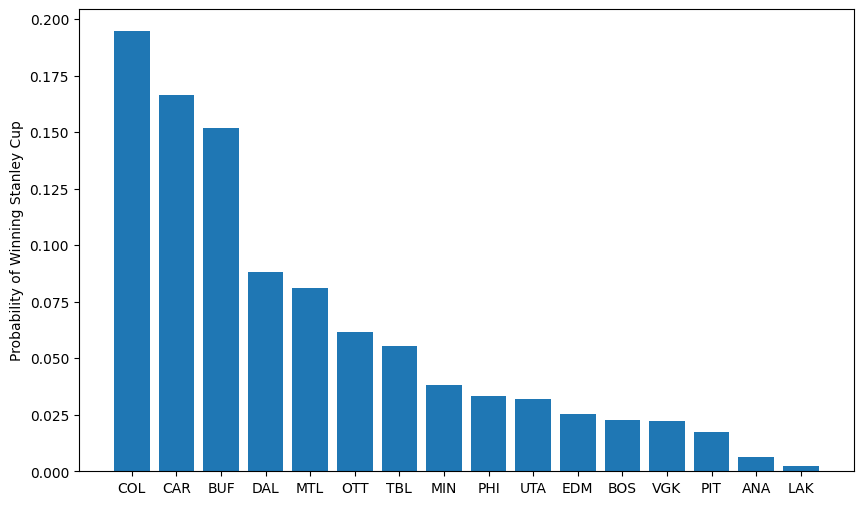

In [23]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10,6))

teams = list(prob_win_cup.keys())
cup_win_probs = list(prob_win_cup.values())

sorted_data = sorted(zip(cup_win_probs, teams), reverse=True)
sorted_values, sorted_categories = zip(*sorted_data)

ax.bar(sorted_categories, sorted_values)

ax.set_ylabel("Probability of Winning Stanley Cup")

plt.show()

Colorado emerges as the most likely winner of the Stanley Cup. This makes sense considering they were ranked third in terms of Elo strength at the start of the playoffs, and finished first overall in league standings at the end of the regular season.

### Expected number of games played

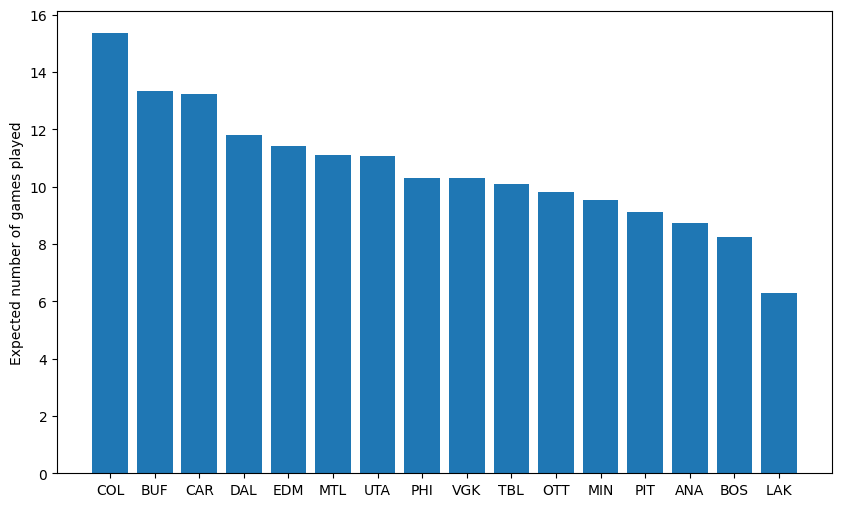

[(15.351145, 'COL'), (13.337275, 'BUF'), (13.22037, 'CAR'), (11.80482, 'DAL'), (11.429745, 'EDM'), (11.11616, 'MTL'), (11.06145, 'UTA'), (10.313495, 'PHI'), (10.301155, 'VGK'), (10.083305, 'TBL'), (9.82666, 'OTT'), (9.52918, 'MIN'), (9.106675, 'PIT'), (8.7488, 'ANA'), (8.232215, 'BOS'), (6.29599, 'LAK')]


In [24]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10,6))

teams = list(expected_games_played.keys())
values = list(expected_games_played.values())

sorted_data = sorted(zip(values, teams), reverse=True)
sorted_values, sorted_categories = zip(*sorted_data)

ax.bar(sorted_categories, sorted_values,)

ax.set_ylabel("Expected number of games played")

plt.show()

print(sorted_data)

The distribution is much flatter than that of the winning Stanley Cup probabilities.

### Expected number of series played

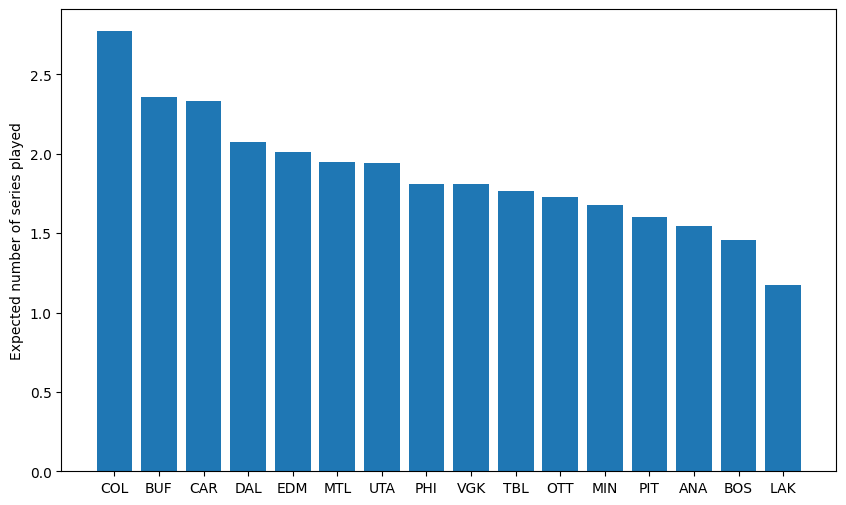

In [25]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10,6))

teams = list(expected_series_played.keys())
values = list(expected_series_played.values())

sorted_data = sorted(zip(values, teams), reverse=True)
sorted_values, sorted_categories = zip(*sorted_data)

ax.bar(sorted_categories, sorted_values,)

ax.set_ylabel("Expected number of series played")

plt.show()

As a generality, the higher rated teams are projected to play more playoff games on average, reflecting their increased likelihood of advancing through multiple rounds of the postseason. Conversely, lower rated teams are expected to play fewer games due to their greater probability of early elimination. As a result of the starting playoff bracket being fixed, some strong teams are forced to play one another in the early rounds, while others benefit from a more favourable path through the bracket. These effects propagate throughout the tournament and influence the expected number of games played. The resulting expected game totals provide the link between the team level Monte Carlo simulations and the player level fantasy projections.

According to the simulations, the Colorado Avalanche emerge as the favourites to win the Stanley Cup with an estimated 19.5% chance of winning. Notably, no team exceeds a 20% probability of becoming champion, illustrating the uncertainty of the NHL playoffs, where even the strongest teams do not have a straightforward path to the Stanley Cup.

# Takeaways and Future Work

I think the simulation framework itself is solid, most advancements to the system would be in regards to the Elo ratings.

## Per game performance variability 
I think it would be interesting to add a per-game randomness factor. Hockey (along with any sport) is inherently difficult to model. Maybe if we added some variability on each game's simulation we could improve simulations. When we think of the delta used in the Elo win probability calculation, we could add some noise. Some pseudocode:
```
 delta = (R_h + h_adv) - R_a
if sigma_elo > 0:
    delta = delta + rng.normal(0.0, sigma_elo)

p_home_win = 1.0 / (1.0 + 10**(-delta / 400.0))
home_team_win = rng.random() < p_home_win
```

sigma_elo should be calibrated. Could do a grid search on noise amounts. Given ratings and regular season games (validation set), we could calculate log-loss of expected outcome and real outcomes for the different noise levels and try to minimise. 

## Team rating variability per playoff simulation
I could at the start of each playoff run add a small amount of noise to each team's rating to give a bit of variability between regular season and playoff strength.

## Fitting parameters for Elo calculations
In the Elo probability calculation, there is a parameter called scale factor set to 400 (which we will just call $s$ for now) by default. In historical terms, it was used when the Elo system was first developed for professional chess ratings and was chosen partially such that the ratings matched a previous rating system in terms of magnitude.

I could try fitting $s$ to minimise log-loss on held-out regular season games (season by season) therefore making the probability calculations more accurate.
